<a href="https://colab.research.google.com/github/KaabachiAlaa/AlaaKaabachiProjectWebsite/blob/main/MLPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


df = pd.read_excel('/content/Dress_Sales(1).xlsx')  # change path if needed
print(f"Loaded: {df.shape}")




Loaded: (500, 14)



### **Data cleaning**
---



In [ ]:
# Fix Rating: 0.0 means missing
df['Rating'] = df['Rating'].replace(0.0, np.nan)

# Unify text syntax (strip + lowercase)
text_cols = ['Style','Price','Size','Season','NeckLine',
             'SleeveLength','waiseline','Material','FabricType',
             'Decoration','Pattern Type']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower().replace('nan', np.nan)

# Fix known typos / variants
df['Season']= df['Season'].replace({'automn': 'autumn'})
df['Size']= df['Size'].replace({'s': 'S', 'small': 'S'})
df['SleeveLength'] = df['SleeveLength'].replace({
    'sleevless': 'sleeveless', 'sleeevless': 'sleeveless', 'sleveless': 'sleeveless',
    'threequater': 'threequarter', 'thressqatar': 'threequarter',
    'halfsleeve': 'half', 'capsleeves': 'cap-sleeves',
    'turndowncollor': 'other', 'urndowncollor': 'other'
})

# Add foldings column (required by model)
df['foldings'] = 'none'

# Fill missing categoricals with mode
for col in text_cols + ['foldings']:
    mode = df[col].mode(dropna=True)
    if len(mode):
        df[col] = df[col].fillna(mode[0])

# Fill missing Rating with median
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

print(f"Missing after cleaning: {df.isnull().sum().sum()}")

Missing after cleaning: 0


### **Data Analysis**

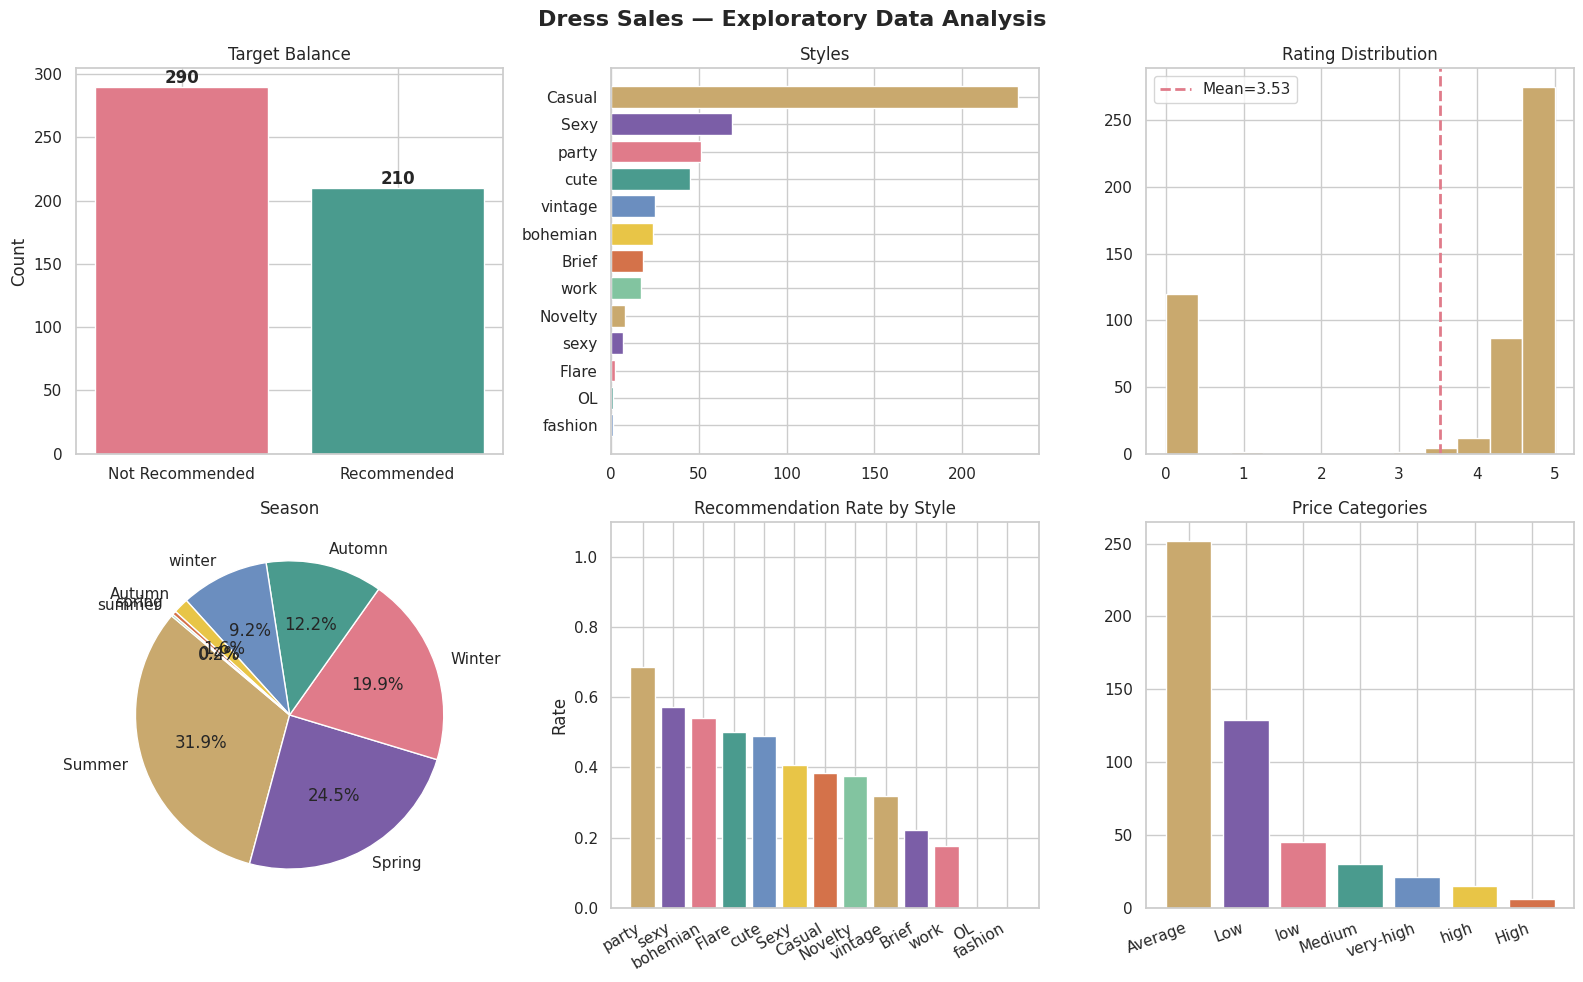

In [ ]:
colors = ['#C9A96E','#7B5EA7','#E07B8A','#4A9B8E','#6B8EBF','#E8C547','#D4724A','#82C4A0']
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Dress Sales — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Target balance
ax = axes[0, 0]
counts = df['Recommendation'].value_counts()
ax.bar(['Not Recommended', 'Recommended'], counts.values, color=[colors[2], colors[3]], edgecolor='white')
ax.set_title('Target Balance')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')

# Style distribution
ax = axes[0, 1]
style_c = df['Style'].value_counts()
ax.barh(style_c.index, style_c.values, color=colors[:len(style_c)], edgecolor='white')
ax.set_title('Styles')
ax.invert_yaxis()

# Rating histogram
ax = axes[0, 2]
ax.hist(df['Rating'], bins=12, color=colors[0], edgecolor='white')
ax.axvline(df['Rating'].mean(), color=colors[2], linestyle='--', linewidth=2,
           label=f"Mean={df['Rating'].mean():.2f}")
ax.set_title('Rating Distribution')
ax.legend()

# Season pie
ax = axes[1, 0]
season_c = df['Season'].value_counts()
ax.pie(season_c.values, labels=season_c.index, autopct='%1.1f%%',
       colors=colors[:len(season_c)], startangle=140, wedgeprops={'edgecolor': 'white'})
ax.set_title('Season')

# Recommendation rate by Style
ax = axes[1, 1]
rec_rate = df.groupby('Style')['Recommendation'].mean().sort_values(ascending=False)
ax.bar(rec_rate.index, rec_rate.values, color=colors[:len(rec_rate)], edgecolor='white')
ax.set_title('Recommendation Rate by Style')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1.1)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Price distribution
ax = axes[1, 2]
price_c = df['Price'].value_counts()
ax.bar(price_c.index, price_c.values, color=colors[:len(price_c)], edgecolor='white')
ax.set_title('Price Categories')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()


### **PREPROCESSING + DATA SPLITTING**

In [ ]:
feature_cols = ['Style','Price','Rating','Size','Season','NeckLine',
                'SleeveLength','waiseline','Material','FabricType',
                'Decoration','Pattern Type','foldings']

X = df[feature_cols].copy()
y = df['Recommendation']

# Label encode categoricals
for col in feature_cols:
    if col != 'Rating':
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")



Train: 400 | Test: 100


### Model Training

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.5700
              precision    recall  f1-score   support

           0       0.62      0.67      0.64        58
           1       0.49      0.43      0.46        42

    accuracy                           0.57       100
   macro avg       0.55      0.55      0.55       100
weighted avg       0.56      0.57      0.57       100



### Model Evaluation

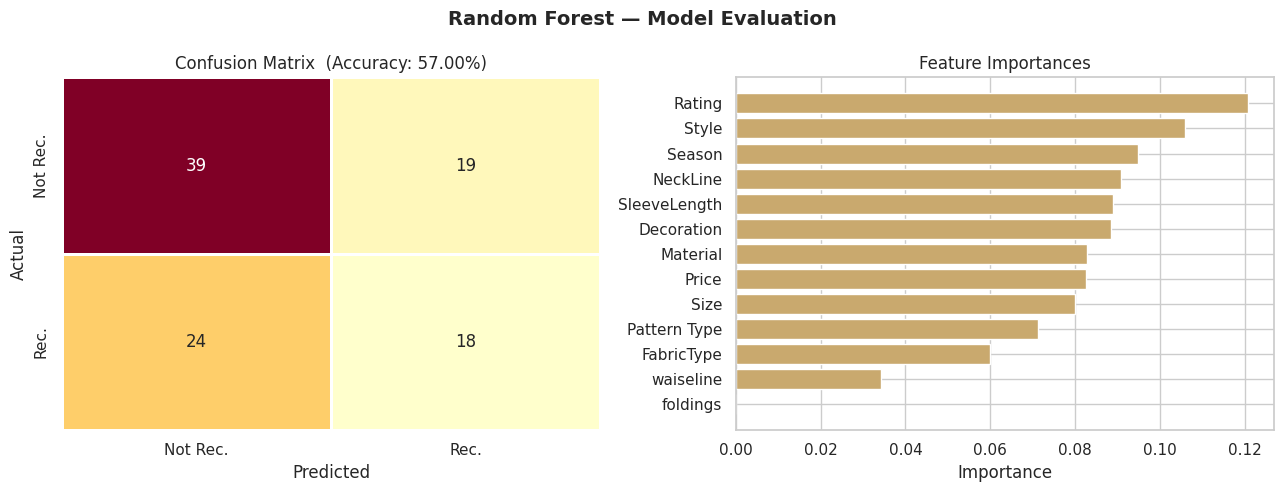

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Random Forest — Model Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=['Not Rec.', 'Rec.'], yticklabels=['Not Rec.', 'Rec.'],
            linewidths=1, cbar=False)
ax.set_title(f'Confusion Matrix  (Accuracy: {accuracy:.2%})')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# Feature importance
ax = axes[1]
imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
ax.barh(imp.index, imp.values, color=colors[0], edgecolor='white')
ax.set_title('Feature Importances')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()